In [1]:
!pip install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.0 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvji

In [2]:
# ========== IMPORT REQUIRED LIBRARIES ==========
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from lightning.pytorch import LightningModule, Trainer
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger
import random
import math
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

## Function and Classes

In [3]:
# Custom Dataset class for loading doctor's handwritten prescription images
# Supports train, validation, and test modes with different data paths
# Encodes medicine names to character indices for CTC loss training
class Dr_Dataset(Dataset):
    def __init__(self, root_dir, mode='train', transform=None, char_to_idx=None):
        self.root_dir = root_dir
        self.mode = mode.lower()
        self.transform = transform

        if self.mode == 'train':
            self.csv_file = os.path.join('/kaggle/working/Augmented_Training', 'training_labels.csv')
            self.image_dir = os.path.join('/kaggle/working/Augmented_Training', 'training_words')
        elif self.mode == 'val':
            self.csv_file = os.path.join(root_dir, 'Validation', 'validation_labels.csv')
            self.image_dir = os.path.join(root_dir, 'Validation', 'validation_words')
        elif self.mode == 'test':
            self.csv_file = os.path.join(root_dir, 'Testing', 'testing_labels.csv')
            self.image_dir = os.path.join(root_dir, 'Testing', 'testing_words')
        else:
            raise ValueError("mode must be 'train', 'val', or 'test'")

        self.df = pd.read_csv(self.csv_file)
        self.img_names = self.df['IMAGE'].values
        self.labels = self.df['MEDICINE_NAME'].astype(str).values

        if char_to_idx is None:
            self.char_to_idx = self._build_char_to_idx(self.labels)
        else:
            self.char_to_idx = char_to_idx

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        label_str = self.labels[idx]

        img_path = os.path.join(self.image_dir, img_name)
        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)
        return img, label_str
        
    def get_valid_labels(self):
        return set(self.labels)
    def _build_char_to_idx(self, labels):
        all_text = ''.join(labels)
        unique_chars = set(all_text)
        char_to_idx = {char: idx + 1 for idx, char in enumerate(sorted(unique_chars))}
        char_to_idx['/'] = 0  
        return char_to_idx

In [4]:
# Custom collate function to stack images and convert labels to strings for DataLoader
def custom_collate_fn(batch):
    images, labels = zip(*batch)

    images = torch.stack(images, 0)

    label_strings = []
    for label in labels:
        if isinstance(label, torch.Tensor):
            label_strings.append("".join([str(x.item()) for x in label]))
        else:
            label_strings.append(str(label))
    
    return images, label_strings

In [5]:
# Word Error Rate (WER) metric - measures similarity between predicted and reference text
# Lower WER means better prediction accuracy
import editdistance

def wer(ref, hyp):
    ref_words = list(ref)
    hyp_words = list(hyp)
    return editdistance.eval(ref_words, hyp_words) / max(len(ref_words), 1)

In [6]:
# Comprehensive test set evaluation - generates predictions and applies error correction
# Returns raw predictions, corrected predictions, and ground truth labels
def evaluate_full_test_set(model, test_dataset, labels, wer_threshold=0.4, batch_size=32):
    model.eval()
    
    raw_predictions = []
    corrected_predictions = []
    true_labels = []
    
    print(f"Evaluating on full test set ({len(test_dataset)} samples)...")
    for idx in tqdm(range(len(test_dataset)), desc="Processing"):
        img, label = test_dataset[idx]
        img = img.unsqueeze(0).to(model.device)
        
        with torch.no_grad():
            logits = model(img)
        
        pred_text_raw = model.decode(logits.cpu())
        
        pred_text_corrected = model.correct_with_fusion(
            pred_text_raw, 
            valid_labels=labels,
            wer_threshold=wer_threshold,
            verbose=False
        )
        
        raw_predictions.append(pred_text_raw[0])
        corrected_predictions.append(pred_text_corrected[0])
        true_labels.append(label)
    
    return {
        'raw_predictions': raw_predictions,
        'corrected_predictions': corrected_predictions,
        'true_labels': true_labels
    }

def calculate_accuracy(predictions, true_labels):
    correct = sum(1 for pred, true in zip(predictions, true_labels) if pred == true)
    total = len(true_labels)
    return correct / total, correct, total

In [7]:
from torchvision import models
import torch.nn.functional as F

class CRNNLit(LightningModule):
    def __init__(self, valid_labels, vocab_size, chars, dropout=0.5, lstm_dropout=0.5):
        super().__init__()
        self.vocab_size = vocab_size
        self.chars = chars
        self.char2idx, self.idx2char = self.char_idx()
        self.valid_labels = valid_labels

        resnet = models.resnet18(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(resnet.children())[:-3])  # bỏ avgpool & fc

        # for param in self.feature_extractor.parameters():
        #     param.requires_grad = False

        self.mapSeq = nn.Sequential(
            nn.Linear(128 * 4, 64), 
            nn.Dropout(dropout),
        )

        self.lstm = nn.LSTM(
            input_size=64, hidden_size=64, num_layers=1,
            dropout=lstm_dropout, bidirectional=True, batch_first=True
        )

        self.out = nn.Linear(128, vocab_size)
        self.criterion = nn.CTCLoss(blank=0, zero_infinity=True)

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.feature_extractor(x)  # (B, C=128, H', W')
        x = x.permute(0, 3, 1, 2)      # (B, W', C, H') → seq_len = W'
        x = x.flatten(2)               # (B, W', C*H')
        x = self.mapSeq(x)            # (B, W', 64)

        x, _ = self.lstm(x)
        x = self.out(x)               # (B, W', vocab_size)
        return x.permute(1, 0, 2)     # (W', B, vocab_size)


    def char_idx(self):
        char2idx = {}
        idx2char = {}
        characters = self.chars
        for i, char in enumerate(characters):
            if char != '/':
                char2idx[char] = i + 1
                idx2char[i + 1] = char
        char2idx['/'] = 0  # CTC blank token
        idx2char[0] = '/'
        return char2idx, idx2char

    def encode(self, labels):
        """Encode a batch of string labels"""
        label_lengths = []
        encoded_labels = []
        
        for label in labels:
            encoded_label = [self.char2idx.get(char, 0) for char in label if char in self.char2idx]
            encoded_labels.extend(encoded_label)
            label_lengths.append(len(encoded_label))
        
        return torch.IntTensor(encoded_labels), torch.IntTensor(label_lengths)

    import editdistance
    @staticmethod
    def wer(ref, hyp):
        ref_words = list(ref)
        hyp_words = list(hyp)
        return editdistance.eval(ref_words, hyp_words) / max(len(ref_words), 1)
    
    def decode(self, logits):
        pred_indices = torch.argmax(logits, dim=2)
        pred_indices = pred_indices.transpose(0, 1)  # (batch, seq_len)
    
        decoded_labels = []
        for batch_idx in range(pred_indices.size(0)):
            seq_indices = pred_indices[batch_idx]
            collapsed_indices = []
            prev_idx = -1
    
            for idx in seq_indices:
                if idx != 0 and idx != prev_idx:
                    collapsed_indices.append(idx)
                prev_idx = idx
    
            decoded_text = "".join([self.idx2char.get(idx.item(), '') for idx in collapsed_indices])
            decoded_labels.append(decoded_text)
    
        return decoded_labels

    def correct_with_fusion(self, decoded_texts, valid_labels=None, wer_threshold=0.4, verbose=False):
        if not valid_labels:
            return decoded_texts
        
        corrected_texts = []
        
        for decoded_text in decoded_texts:
            best_match = decoded_text
            min_wer = 1.0
            
            if verbose:
                print(f"Decoded raw: {decoded_text}")
            
            for label in valid_labels:
                cur_wer = self.wer(decoded_text, label)
                if cur_wer < min_wer:
                    min_wer = cur_wer
                    best_match = label
                    
                if verbose:
                    print(f"  Candidate: {label}, WER: {cur_wer:.3f}")
            
            if min_wer <= wer_threshold:
                corrected_text = best_match
                if verbose:
                    print(f"  -> Corrected to: {corrected_text} (WER: {min_wer:.3f})")
            else:
                corrected_text = decoded_text
                if verbose:
                    print(f"  -> No correction applied (min WER: {min_wer:.3f} > {wer_threshold})")
            
            corrected_texts.append(corrected_text)
        
        return corrected_texts
    
    def calculate_loss(self, logits, labels):
        encoded_labels, label_lengths = self.encode(labels)
        logits_lens = torch.full(
            size=(logits.size(1),), fill_value=logits.size(0), dtype=torch.int32
        ).to(self.device)
        
        loss = self.criterion(
            logits.log_softmax(2),
            encoded_labels.to(self.device),
            logits_lens,
            label_lengths.to(self.device),
        )
        
        return loss

    def training_step(self, batch, batch_idx):
        images, labels = batch
        logits = self(images)
        loss = self.calculate_loss(logits, labels)
        current_lr = self.optimizers().param_groups[0]['lr']
        
        self.log("lr", current_lr, on_step=True, prog_bar=True, logger=True)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        logits = self(images)
        loss = self.calculate_loss(logits, labels)
    
        decoded = self.decode(logits)
    
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=1e-3,
            weight_decay=5e-3, 
            betas=(0.9, 0.999),
            eps=1e-8
        )
    
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=5,        # số epoch để hoàn thành một chu kỳ cosine
            eta_min=1e-4     # learning rate nhỏ nhất
        )
    
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'interval': 'epoch',
                'frequency': 1
            }
        }


## Augmentation 

In [8]:
# ========== DATA AUGMENTATION ==========
# Apply transformations to training images: rotation, color jitter, translation
# Generate 5 augmented copies for each image to increase dataset size
original_dir = '/kaggle/input/doctors-handwritten-prescription-bd-dataset/Doctor’s Handwritten Prescription BD dataset/Training'
new_dir = '/kaggle/working/Augmented_Training'

original_img_dir = os.path.join(original_dir, 'training_words')
new_img_dir = os.path.join(new_dir, 'training_words')
os.makedirs(new_img_dir, exist_ok=True)


df = pd.read_csv(os.path.join(original_dir, 'training_labels.csv'))

augment_transform = transforms.Compose([
    transforms.Resize((32, 128)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomRotation(degrees=3),
    transforms.RandomAffine(degrees=0, translate=(0.07, 0.07)),
    transforms.ToTensor()
])

new_rows = []

for idx, row in df.iterrows():
    img_name = row['IMAGE']
    label = row['MEDICINE_NAME']
    img_path = os.path.join(original_img_dir, img_name)

    image = Image.open(img_path).convert('RGB')
    image.save(os.path.join(new_img_dir, img_name))
    new_rows.append({'IMAGE': img_name, 'MEDICINE_NAME': label})

    for i in range(5):  
        aug_img = augment_transform(image)
        aug_img_pil = transforms.ToPILImage()(aug_img)
        new_img_name = f"{os.path.splitext(img_name)[0]}_aug{i+1}.jpg"
        aug_img_pil.save(os.path.join(new_img_dir, new_img_name))
        new_rows.append({'IMAGE': new_img_name, 'MEDICINE_NAME': label})

new_df = pd.DataFrame(new_rows)
new_df.to_csv(os.path.join(new_dir, 'training_labels.csv'), index=False)

print("✅ Augmentation complete. New dataset saved to:", new_dir)

✅ Augmentation complete. New dataset saved to: /kaggle/working/Augmented_Training


## Load dataset

In [9]:
# ========== LOAD DATASETS ==========
# Create train/val/test datasets and DataLoaders with custom collate function
# Batch size: 32, using multi-processing for faster data loading
DATA_DIR = '/kaggle/input/doctors-handwritten-prescription-bd-dataset/Doctor’s Handwritten Prescription BD dataset'

transform = transforms.Compose([
    transforms.Resize((32, 128)),
    transforms.ToTensor(),
])


train_dataset = Dr_Dataset(DATA_DIR, mode='train', transform=transform)
val_dataset = Dr_Dataset(DATA_DIR, mode='val', transform=transform, char_to_idx=train_dataset.char_to_idx)
test_dataset = Dr_Dataset(DATA_DIR, mode='test', transform=transform, char_to_idx=train_dataset.char_to_idx)

train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True, 
    num_workers=2, 
    collate_fn=custom_collate_fn
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=2, 
    collate_fn=custom_collate_fn
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=2, 
    collate_fn=custom_collate_fn
)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Character to index mapping: {train_dataset.char_to_idx}")


Number of training samples: 18720
Number of validation samples: 780
Number of test samples: 780
Character to index mapping: {' ': 1, '-': 2, 'A': 3, 'B': 4, 'C': 5, 'D': 6, 'E': 7, 'F': 8, 'K': 9, 'L': 10, 'M': 11, 'N': 12, 'O': 13, 'P': 14, 'R': 15, 'S': 16, 'T': 17, 'V': 18, 'Z': 19, 'a': 20, 'b': 21, 'c': 22, 'd': 23, 'e': 24, 'f': 25, 'g': 26, 'h': 27, 'i': 28, 'k': 29, 'l': 30, 'm': 31, 'n': 32, 'o': 33, 'p': 34, 'r': 35, 's': 36, 't': 37, 'u': 38, 'v': 39, 'x': 40, 'y': 41, 'z': 42, '/': 0}


In [10]:
labels = train_dataset.get_valid_labels()
print(labels)

{'M-Kast', 'Montene', 'Lumona', 'Baclon', 'Rozith', 'Azyth', 'Baclofen', 'Maxpro', 'Sergel', 'Flexilax', 'Opton', 'Provair', 'Ketozol', 'Azithrocin', 'Romycin', 'Progut', 'Etizin', 'Metsina', 'Ketocon', 'Odmon', 'Telfast', 'Metro', 'Exium', 'Axodin', 'Diflu', 'Conaz', 'Ritch', 'Az', 'Napa', 'Canazole', 'Omastin', 'Beklo', 'Maxima', 'Zithrin', 'Rivotril', 'Montair', 'Filmet', 'Rhinil', 'Trilock', 'Esoral', 'Flugal', 'Amodis', 'Ketotab', 'Esonix', 'Cetisoft', 'Fenadin', 'Flexibac', 'Denixil', 'Fixal', 'Bacmax', 'Vifas', 'Tridosil', 'Nidazyl', 'Montex', 'Dancel', 'Ace', 'Candinil', 'Fexofast', 'Bicozin', 'Napa Extend', 'Nexcap', 'Tamen', 'Leptic', 'Lucan-R', 'Monas', 'Ketoral', 'Fexo', 'Backtone', 'Nizoder', 'Dinafex', 'Flamyd', 'Atrizin', 'Alatrol', 'Aceta', 'Bacaid', 'Disopan', 'Nexum', 'Renova'}


In [11]:

CHARS = "".join(sorted([k for k in train_dataset.char_to_idx.keys() if k != '-']))
VOCAB_SIZE = len(train_dataset.char_to_idx)
print(f"Characters: {CHARS}")
print(f"Vocabulary size: {VOCAB_SIZE}")

Characters:  /ABCDEFKLMNOPRSTVZabcdefghiklmnoprstuvxyz
Vocabulary size: 43


## Training

In [12]:
# ========== MODEL TRAINING ==========
# Initialize CRNN model with LightningModule
# Setup callbacks: Early Stopping (patience=10), Model Checkpoint for best model
# Train with GPU acceleration using PyTorch Lightning
model = CRNNLit(valid_labels=labels, vocab_size=VOCAB_SIZE, chars=CHARS)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    mode='min',
    verbose=True
)

checkpoint = ModelCheckpoint(
    monitor='val_loss',
    dirpath='checkpoints',
    filename='crnn-best',
    save_top_k=1,
    mode='min'
)

logger = CSVLogger(save_dir='logs', name='CRNN')

trainer = Trainer(
    max_epochs=-1,
    callbacks=[early_stop, checkpoint],
    logger=logger,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    log_every_n_steps=10,
    gradient_clip_val=5.0,
    limit_train_batches=0.8,
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater

┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ feature_extractor │ Sequential │  2.8 M │ train │     0 │
│ 1 │ mapSeq            │ Sequential │ 32.8 K │ train │     0 │
│ 2 │ lstm              │ LSTM       │ 66.6 K │ train │     0 │
│ 3 │ out               │ Linear     │  5.5 K │ train │     0 │
│ 4 │ criterion         │ CTCLoss    │      0 │ train │     0 │
└───┴───────────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 2.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.9 M                                                                                                
Total estimated model params size (MB): 11                                                                         
Modules in train mode: 56                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` 
from an ambiguous collection. The batch size we found is 32. To avoid any miscalculations, use `self.log(..., 
batch_size=batch_size)`.

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` 
from an ambiguous collection. The batch size we found is 12. To avoid any miscalculations, use `self.log(..., 
batch_size=batch_size)`.

INFO: Metric val_loss improved. New best score: 1.254
INFO: Metric val_loss improved by 0.833 >= min_delta = 0.0. New best score: 0.421
INFO: Metric val_loss improved by 0.137 >= min_delta = 0.0. New best score: 0.284
INFO: Metric val_loss improved by 0.028 >= min_delta = 0.0. New best score: 0.256
INFO: Metric val_loss improved by 0.016 >= min_delta = 0.0. New best score: 0.239
INFO: Metric val_loss improved by 0.026 >= min_delta = 0.0. New best score: 0.213
INFO: Monitored metric val_loss did not improve in the last 10 records. Best score: 0.213. Signaling Trainer to stop.


## Test and show results

In [13]:
# ========== TEST EVALUATION ==========
# Load the best model checkpoint from training
# Run comprehensive evaluation on full test set
best_model_path = checkpoint.best_model_path
best_model = CRNNLit.load_from_checkpoint(best_model_path, valid_labels=labels, vocab_size=VOCAB_SIZE, chars=CHARS)
best_model.eval()

CRNNLit(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_s

Evaluating on full test set (780 samples)...


Processing: 100%|██████████| 780/780 [00:09<00:00, 82.94it/s]



FULL TEST SET EVALUATION RESULTS
Total test samples: 780
Raw predictions accuracy: 605/780 = 0.7756 (77.56%)
Corrected predictions accuracy: 699/780 = 0.8962 (89.62%)
Improvement: 0.1205 (12.05%)


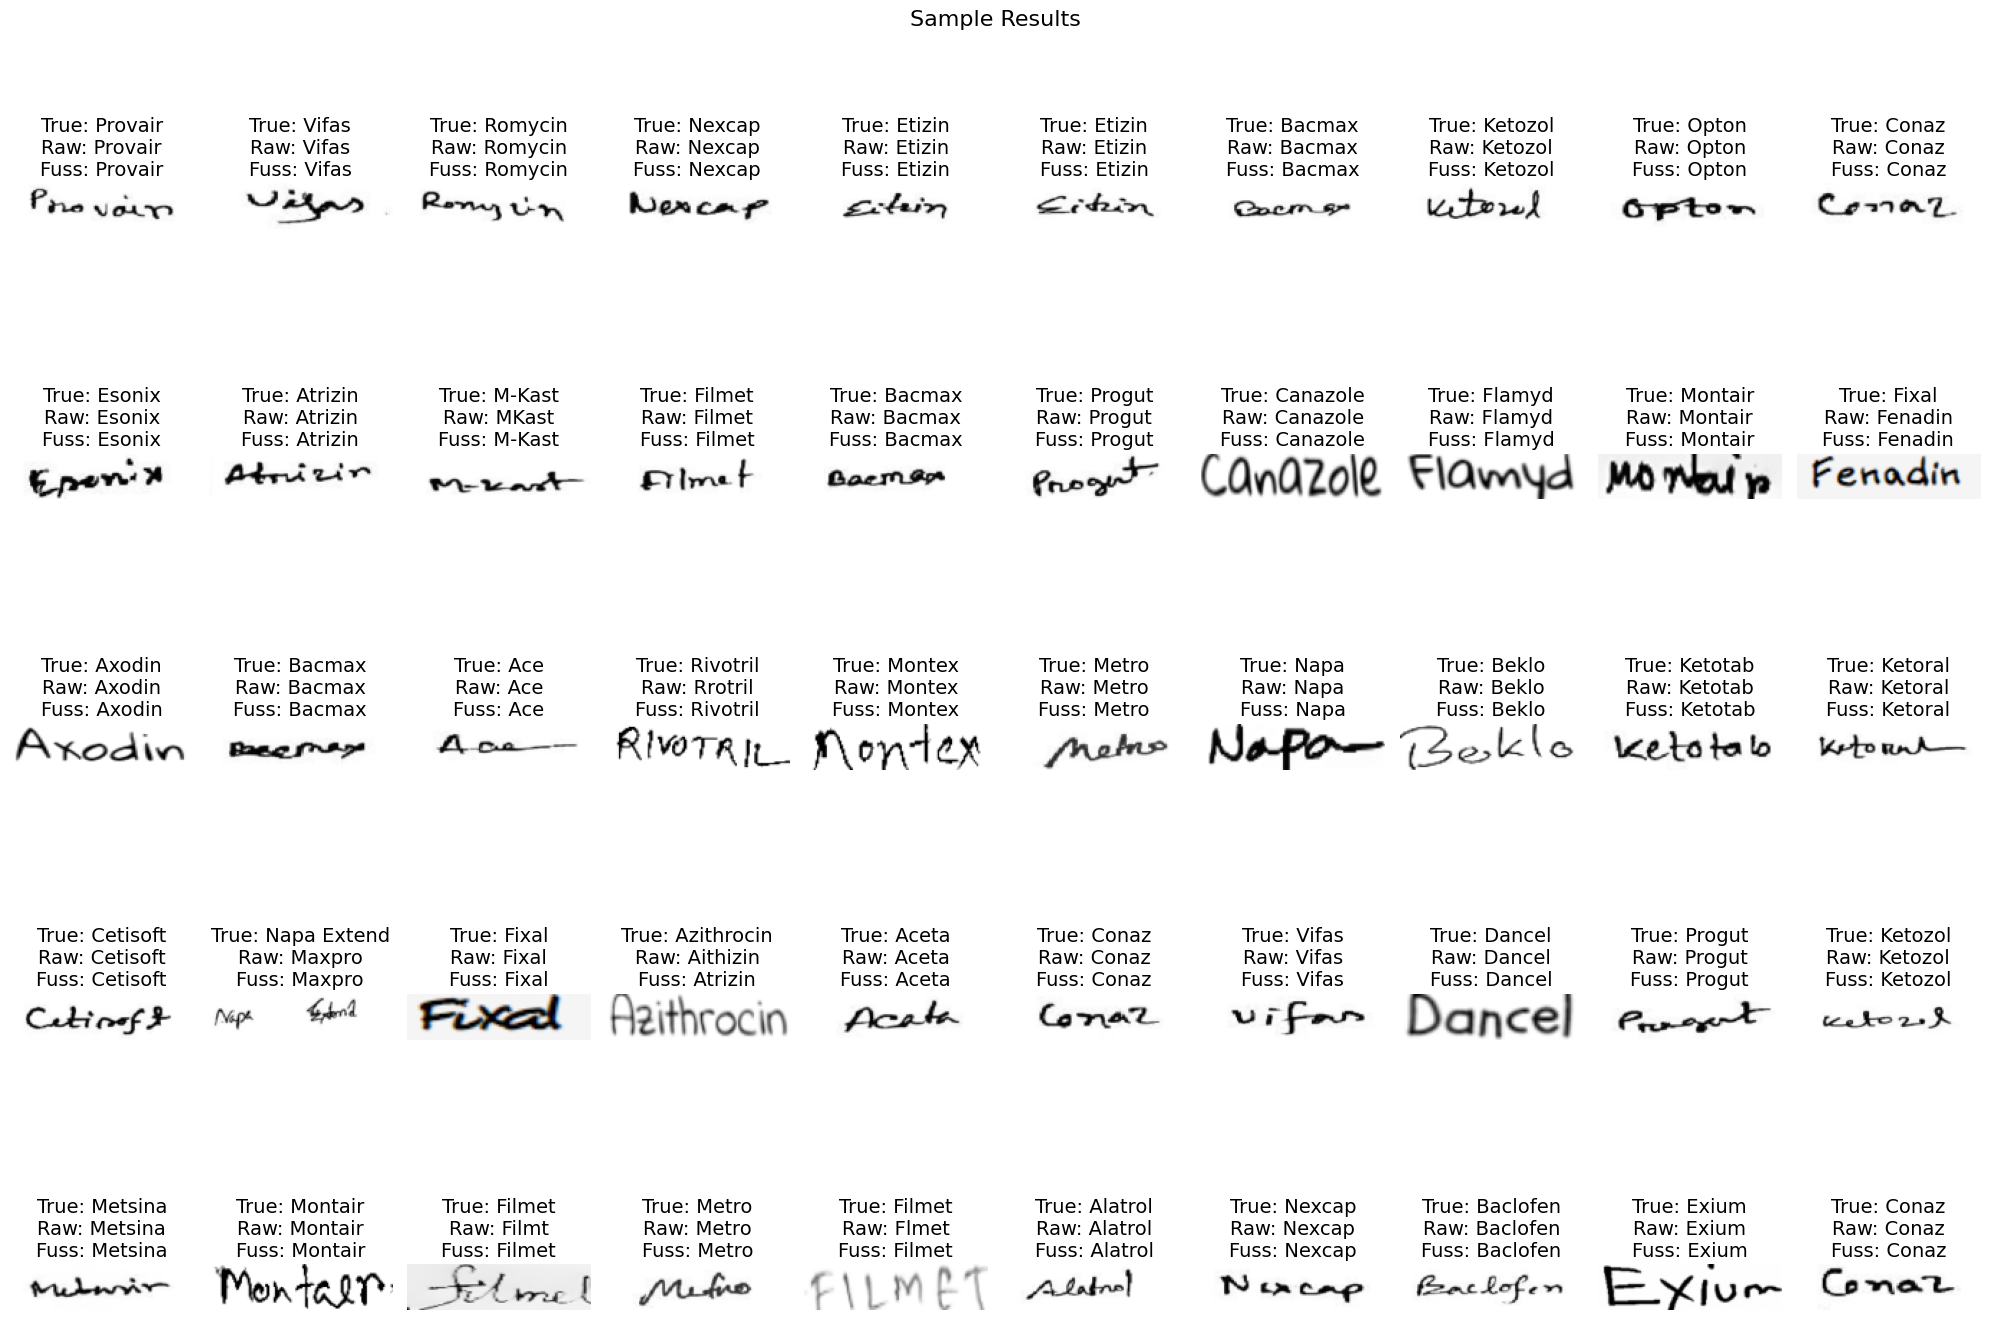

In [14]:


full_results = evaluate_full_test_set(
    model=best_model,
    test_dataset=test_dataset,
    labels=labels, 
    wer_threshold=0.4
)

raw_accuracy, raw_correct, total = calculate_accuracy(
    full_results['raw_predictions'], 
    full_results['true_labels']
)

corrected_accuracy, corrected_correct, _ = calculate_accuracy(
    full_results['corrected_predictions'], 
    full_results['true_labels']
)

print("\n" + "="*50)
print("FULL TEST SET EVALUATION RESULTS")
print("="*50)
print(f"Total test samples: {total}")
print(f"Raw predictions accuracy: {raw_correct}/{total} = {raw_accuracy:.4f} ({raw_accuracy*100:.2f}%)")
print(f"Corrected predictions accuracy: {corrected_correct}/{total} = {corrected_accuracy:.4f} ({corrected_accuracy*100:.2f}%)")
print(f"Improvement: {corrected_accuracy - raw_accuracy:.4f} ({(corrected_accuracy - raw_accuracy)*100:.2f}%)")
print("="*50)

sample_indices = np.random.choice(len(test_dataset), size=50, replace=False)
sample_results = []

for idx in sample_indices:
    img, label = test_dataset[idx]
    sample_results.append((
        img.permute(1, 2, 0),
        label,
        full_results['raw_predictions'][idx],
        full_results['corrected_predictions'][idx]
    ))


fig, axes = plt.subplots(5, 10, figsize=(20, 15))
axes = axes.flatten()

for i, (img, true_label, pred_raw, pred_corrected) in enumerate(sample_results):
    ax = axes[i]
    ax.imshow(img)
    
    # Color coding: green if correct, red if wrong
    raw_color = 'green' if pred_raw == true_label else 'red'
    corr_color = 'green' if pred_corrected == true_label else 'red'
    
    ax.set_title(
        f"True: {true_label}\n"
        f"Raw: {pred_raw}\n"
        f"Fuss: {pred_corrected}", 
        fontsize=14,
        color='black'
    )
    ax.axis('off')

plt.suptitle('Sample Results', 
             fontsize=16)
plt.tight_layout()
plt.show()


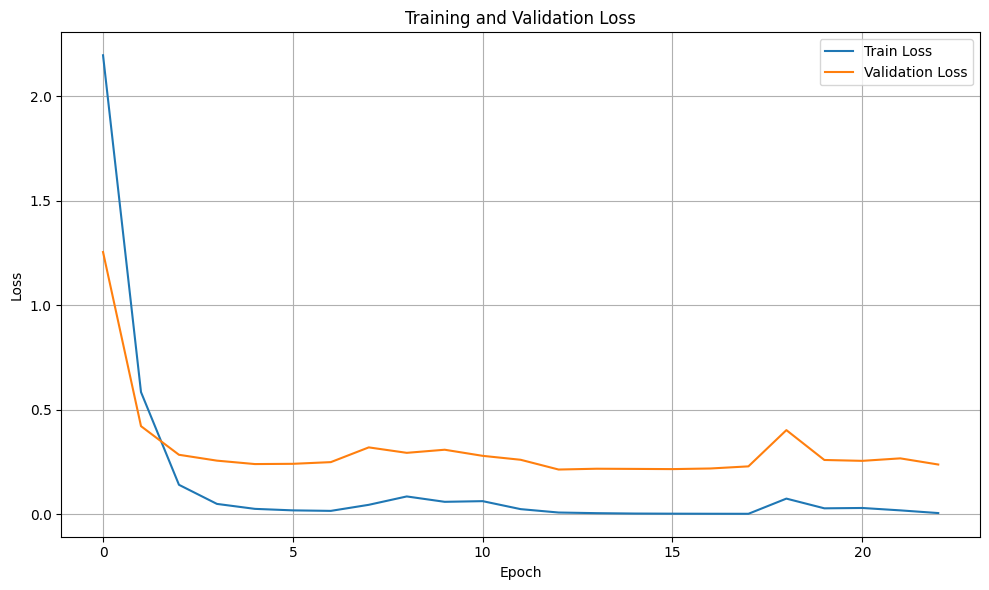

In [15]:
log_path = "/kaggle/working/logs/CRNN/version_0/metrics.csv"
df = pd.read_csv(log_path)
df_train = df[["epoch", "train_loss_epoch"]].dropna()
df_val = df[["epoch", "val_loss"]].dropna()

plt.figure(figsize=(10, 6)) 
plt.plot(df_train["epoch"], df_train["train_loss_epoch"], label="Train Loss") 
plt.plot(df_val["epoch"], df_val["val_loss"], label="Validation Loss") 
plt.xlabel("Epoch") 
plt.ylabel("Loss") 
plt.title("Training and Validation Loss") 
plt.legend() 
plt.grid(True) 
plt.tight_layout()
plt.show()

In [16]:
# ========== DIAGNOSIS SYSTEM WITH IMAGE HIGHLIGHTING ==========
# Predict diseases based on extracted medicine names and highlight prescription images
# Provides detailed medical explanations for each diagnosis

# Comprehensive medicine-to-disease mapping database
medicine_disease_database = {
    # ANTIBIOTICS (Bacterial/Respiratory Infections)
    'Azithrocin': {
        'disease': 'Bacterial Infection',
        'category': 'Infection',
        'severity': 'Moderate',
        'explanation': 'Azithrocin is a macrolide antibiotic used to treat bacterial infections. Prescribed for respiratory tract infections, skin infections, and other bacterial conditions.',
        'symptoms': ['Fever', 'Cough', 'Sore throat', 'Body ache']
    },
    'Romycin': {
        'disease': 'Respiratory Infection',
        'category': 'Infection',
        'severity': 'Moderate',
        'explanation': 'Romycin treats respiratory infections including bronchitis and pneumonia. It is effective against gram-positive bacteria.',
        'symptoms': ['Persistent cough', 'Shortness of breath', 'Chest pain']
    },
    'Metro': {
        'disease': 'Parasitic/Gastrointestinal Infection',
        'category': 'Infection',
        'severity': 'Moderate',
        'explanation': 'Metronidazole (Metro) is used to treat parasitic and anaerobic bacterial infections of the GI tract.',
        'symptoms': ['Diarrhea', 'Abdominal pain', 'Nausea']
    },
    
    # ANTIHISTAMINES & ALLERGY MEDICATIONS
    'Atrizin': {
        'disease': 'Allergic Rhinitis/Allergy',
        'category': 'Allergy',
        'severity': 'Mild-Moderate',
        'explanation': 'Atrizin (Cetirizine) is an antihistamine for allergic rhinitis, urticaria, and itching. Works by blocking histamine receptors.',
        'symptoms': ['Sneezing', 'Runny nose', 'Itching', 'Watery eyes']
    },
    'Telfast': {
        'disease': 'Seasonal Allergies',
        'category': 'Allergy',
        'severity': 'Mild',
        'explanation': 'Telfast (Fexofenadine) is a second-generation antihistamine. Non-drowsy option for allergic conditions.',
        'symptoms': ['Rhinitis', 'Urticaria', 'Pruritus']
    },
    
    # ANTIFUNGAL MEDICATIONS
    'Ketocon': {
        'disease': 'Fungal Infection',
        'category': 'Infection',
        'severity': 'Mild-Moderate',
        'explanation': 'Ketoconazole treats fungal infections including candidiasis and dermatophyte infections.',
        'symptoms': ['Itching', 'Redness', 'Scaling', 'Discharge']
    },
    'Nizoder': {
        'disease': 'Fungal/Dandruff',
        'category': 'Skin',
        'severity': 'Mild',
        'explanation': 'Nizoral (Ketoconazole) shampoo for scalp fungal infections, seborrheic dermatitis, and dandruff control.',
        'symptoms': ['Flaking', 'Itching scalp', 'Dry skin']
    },
    
    # ANALGESICS & ANTI-INFLAMMATORY
    'Napa': {
        'disease': 'Pain/Fever',
        'category': 'Pain Management',
        'severity': 'Mild',
        'explanation': 'Paracetamol/Acetaminophen for mild to moderate pain and fever management.',
        'symptoms': ['Headache', 'Fever', 'Muscle aches']
    },
    'Napa Extend': {
        'disease': 'Prolonged Pain/Fever',
        'category': 'Pain Management',
        'severity': 'Mild',
        'explanation': 'Extended-release paracetamol for sustained pain relief over 8-12 hours.',
        'symptoms': ['Chronic headache', 'Persistent fever']
    },
    
    # RESPIRATORY MEDICATIONS (Asthma/Cough)
    'Montair': {
        'disease': 'Asthma/Chronic Cough',
        'category': 'Respiratory',
        'severity': 'Moderate',
        'explanation': 'Montelukast for asthma and allergic rhinitis. Leukotriene receptor antagonist that prevents airway inflammation.',
        'symptoms': ['Wheezing', 'Shortness of breath', 'Chronic cough']
    },
    'Monas': {
        'disease': 'Asthma',
        'category': 'Respiratory',
        'severity': 'Moderate',
        'explanation': 'Another form of montelukast, used for long-term asthma control and prevention of asthma attacks.',
        'symptoms': ['Wheezing', 'Chest tightness', 'Difficulty breathing']
    },
    'M-Kast': {
        'disease': 'Asthma',
        'category': 'Respiratory',
        'severity': 'Moderate',
        'explanation': 'Montelukast formulation for maintenance therapy of asthma in adults and children.',
        'symptoms': ['Nocturnal asthma', 'Exercise-induced asthma']
    },
    
    # MUSCLE RELAXANTS & NEUROLOGICAL
    'Baclofen': {
        'disease': 'Muscle Spasm/Muscle Rigidity',
        'category': 'Neurological',
        'severity': 'Moderate',
        'explanation': 'Baclofen is a muscle relaxant and GABA agonist used for spasticity and muscle rigidity from neurological conditions.',
        'symptoms': ['Muscle spasms', 'Stiffness', 'Pain from muscle tension']
    },
    'Baclon': {
        'disease': 'Muscle Spasm',
        'category': 'Neurological',
        'severity': 'Moderate',
        'explanation': 'Another formulation of baclofen for relief of muscle spasms and hypertonicity.',
        'symptoms': ['Acute muscle pain', 'Spasticity']
    },
    'Rivotril': {
        'disease': 'Seizures/Anxiety',
        'category': 'Neurological',
        'severity': 'High',
        'explanation': 'Clonazepam (Rivotril) is a benzodiazepine for seizure disorders, panic disorder, and anxiety management.',
        'symptoms': ['Seizures', 'Muscle jerks', 'Anxiety']
    },
}

print(f"\u2705 Loaded diagnosis database with {len(medicine_disease_database)} medicines")
print(f"Categories: {set([v['category'] for v in medicine_disease_database.values()])}")

✅ Loaded diagnosis database with 15 medicines
Categories: {'Infection', 'Pain Management', 'Respiratory', 'Neurological', 'Skin', 'Allergy'}


In [17]:
# Diagnosis Functions
def diagnose_from_medicine(medicine_name):
    medicine_name = medicine_name.strip()
    if medicine_name in medicine_disease_database:
        return medicine_disease_database[medicine_name]
    else:
        return {
            'disease': 'Unknown Medicine',
            'category': 'Not in Database',
            'severity': 'Unknown',
            'explanation': f'Medicine "{medicine_name}" not found',
            'symptoms': []
        }

def diagnose_prescription(medicines_list):
    diagnoses = []
    categories = {}
    severities = []
    
    for med in medicines_list:
        if med:
            diag = diagnose_from_medicine(med)
            diagnoses.append({'medicine': med, 'diagnosis': diag})
            cat = diag['category']
            categories[cat] = categories.get(cat, 0) + 1
            severities.append(diag['severity'])
    
    return {
        'medicines': medicines_list,
        'individual_diagnoses': diagnoses,
        'categories': categories,
        'total_medicines': len(medicines_list),
        'primary_categories': sorted(categories.items(), key=lambda x: x[1], reverse=True)
    }

print(u'\u2705 Diagnosis functions loaded')

✅ Diagnosis functions loaded


In [18]:
# ========== DIAGNOSIS VISUALIZATION WITH IMAGE HIGHLIGHTING ==========
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

def visualize_diagnosis_with_highlighting(image_array, medicine_name, diagnosis_info):
    """
    Create highlighted visualization of prescription with diagnosis
    Shows: Image | Diagnosis Details | Medical Explanation
    """
    fig, (ax_img, ax_info) = plt.subplots(1, 2, figsize=(16, 6))
    
    # LEFT: Image with highlighting based on severity
    ax_img.imshow(image_array)
    
    # Color code by severity
    severity_colors = {
        'Low': 'green',
        'Mild': 'yellow',
        'Mild-Moderate': 'orange',
        'Moderate': 'red',
        'High': 'darkred',
        'Unknown': 'gray'
    }
    
    severity = diagnosis_info.get('severity', 'Unknown')
    color = severity_colors.get(severity, 'gray')
    edge_width = 4 if severity in ['High', 'Moderate'] else 2
    
    # Add colored border to highlight severity
    rect = Rectangle((0, 0), image_array.shape[1], image_array.shape[0], 
                     linewidth=edge_width, edgecolor=color, facecolor='none')
    ax_img.add_patch(rect)
    
    # Add severity badge
    severity_text = f"SEVERITY: {severity}"
    ax_img.text(10, 20, severity_text, color='white', fontsize=12, 
               fontweight='bold', bbox=dict(boxstyle='round', facecolor=color, alpha=0.8))
    
    ax_img.axis('off')
    ax_img.set_title(f"Medicine: {medicine_name}", fontsize=14, fontweight='bold')
    
    # RIGHT: Diagnosis Information
    ax_info.axis('off')
    
    # Create text information
    info_text = f"""
╔═══════════════════════════════════════════════════════════╗
║              DIAGNOSIS & MEDICAL DETAILS                  ║
╚═══════════════════════════════════════════════════════════╝

🔹 MEDICINE NAME:
   {medicine_name}

🔹 PRIMARY DIAGNOSIS:
   {diagnosis_info.get('disease', 'Unknown')}

🔹 CATEGORY:
   {diagnosis_info.get('category', 'Unknown')}

🔹 SEVERITY LEVEL:
   {severity}

🔹 MEDICAL EXPLANATION:
   {diagnosis_info.get('explanation', 'No explanation available')}

🔹 COMMON SYMPTOMS:
   {', '.join(diagnosis_info.get('symptoms', ['No symptoms listed']))}

═════════════════════════════════════════════════════════════
"""
    
    ax_info.text(0.05, 0.95, info_text, transform=ax_info.transAxes,
                fontsize=10, verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    
    plt.tight_layout()
    return fig

print(u'\u2705 Visualization function loaded')

✅ Visualization function loaded


🔧 Kaggle GPU Setup...
📁 Found irma: /kaggle/input/irma-xray-dataset
❌ Dataset not found: chestxray
❌ Dataset not found: prescription
📊 Dataset ready: 200 X-rays
Dataset columns: ['path', 'source', 'ocr']
🎯 Device: cuda


2025-12-30 11:01:55.383308: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767092515.531955      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767092515.575231      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/575 [00:00<?, ?B/s]

...

  0%|          | 0/15 [00:00<?, ?it/s]

Processing:  96%|█████████▌| 23/24 [05:01<00:12, 12.70s/it]

  0%|          | 0/15 [00:00<?, ?it/s]

Processing: 100%|██████████| 24/24 [05:14<00:00, 13.10s/it]


✅ Processed 24 X-rays

🎯 RESULTS SUMMARY:
Valid cases: 24
Normal: 0.0% | Anomalies: 100.0%

📈 PERFORMANCE BY SOURCE:
       anomaly_score                ssim
                mean    std count   mean
source                                  
irma           0.772  0.082    24  0.054


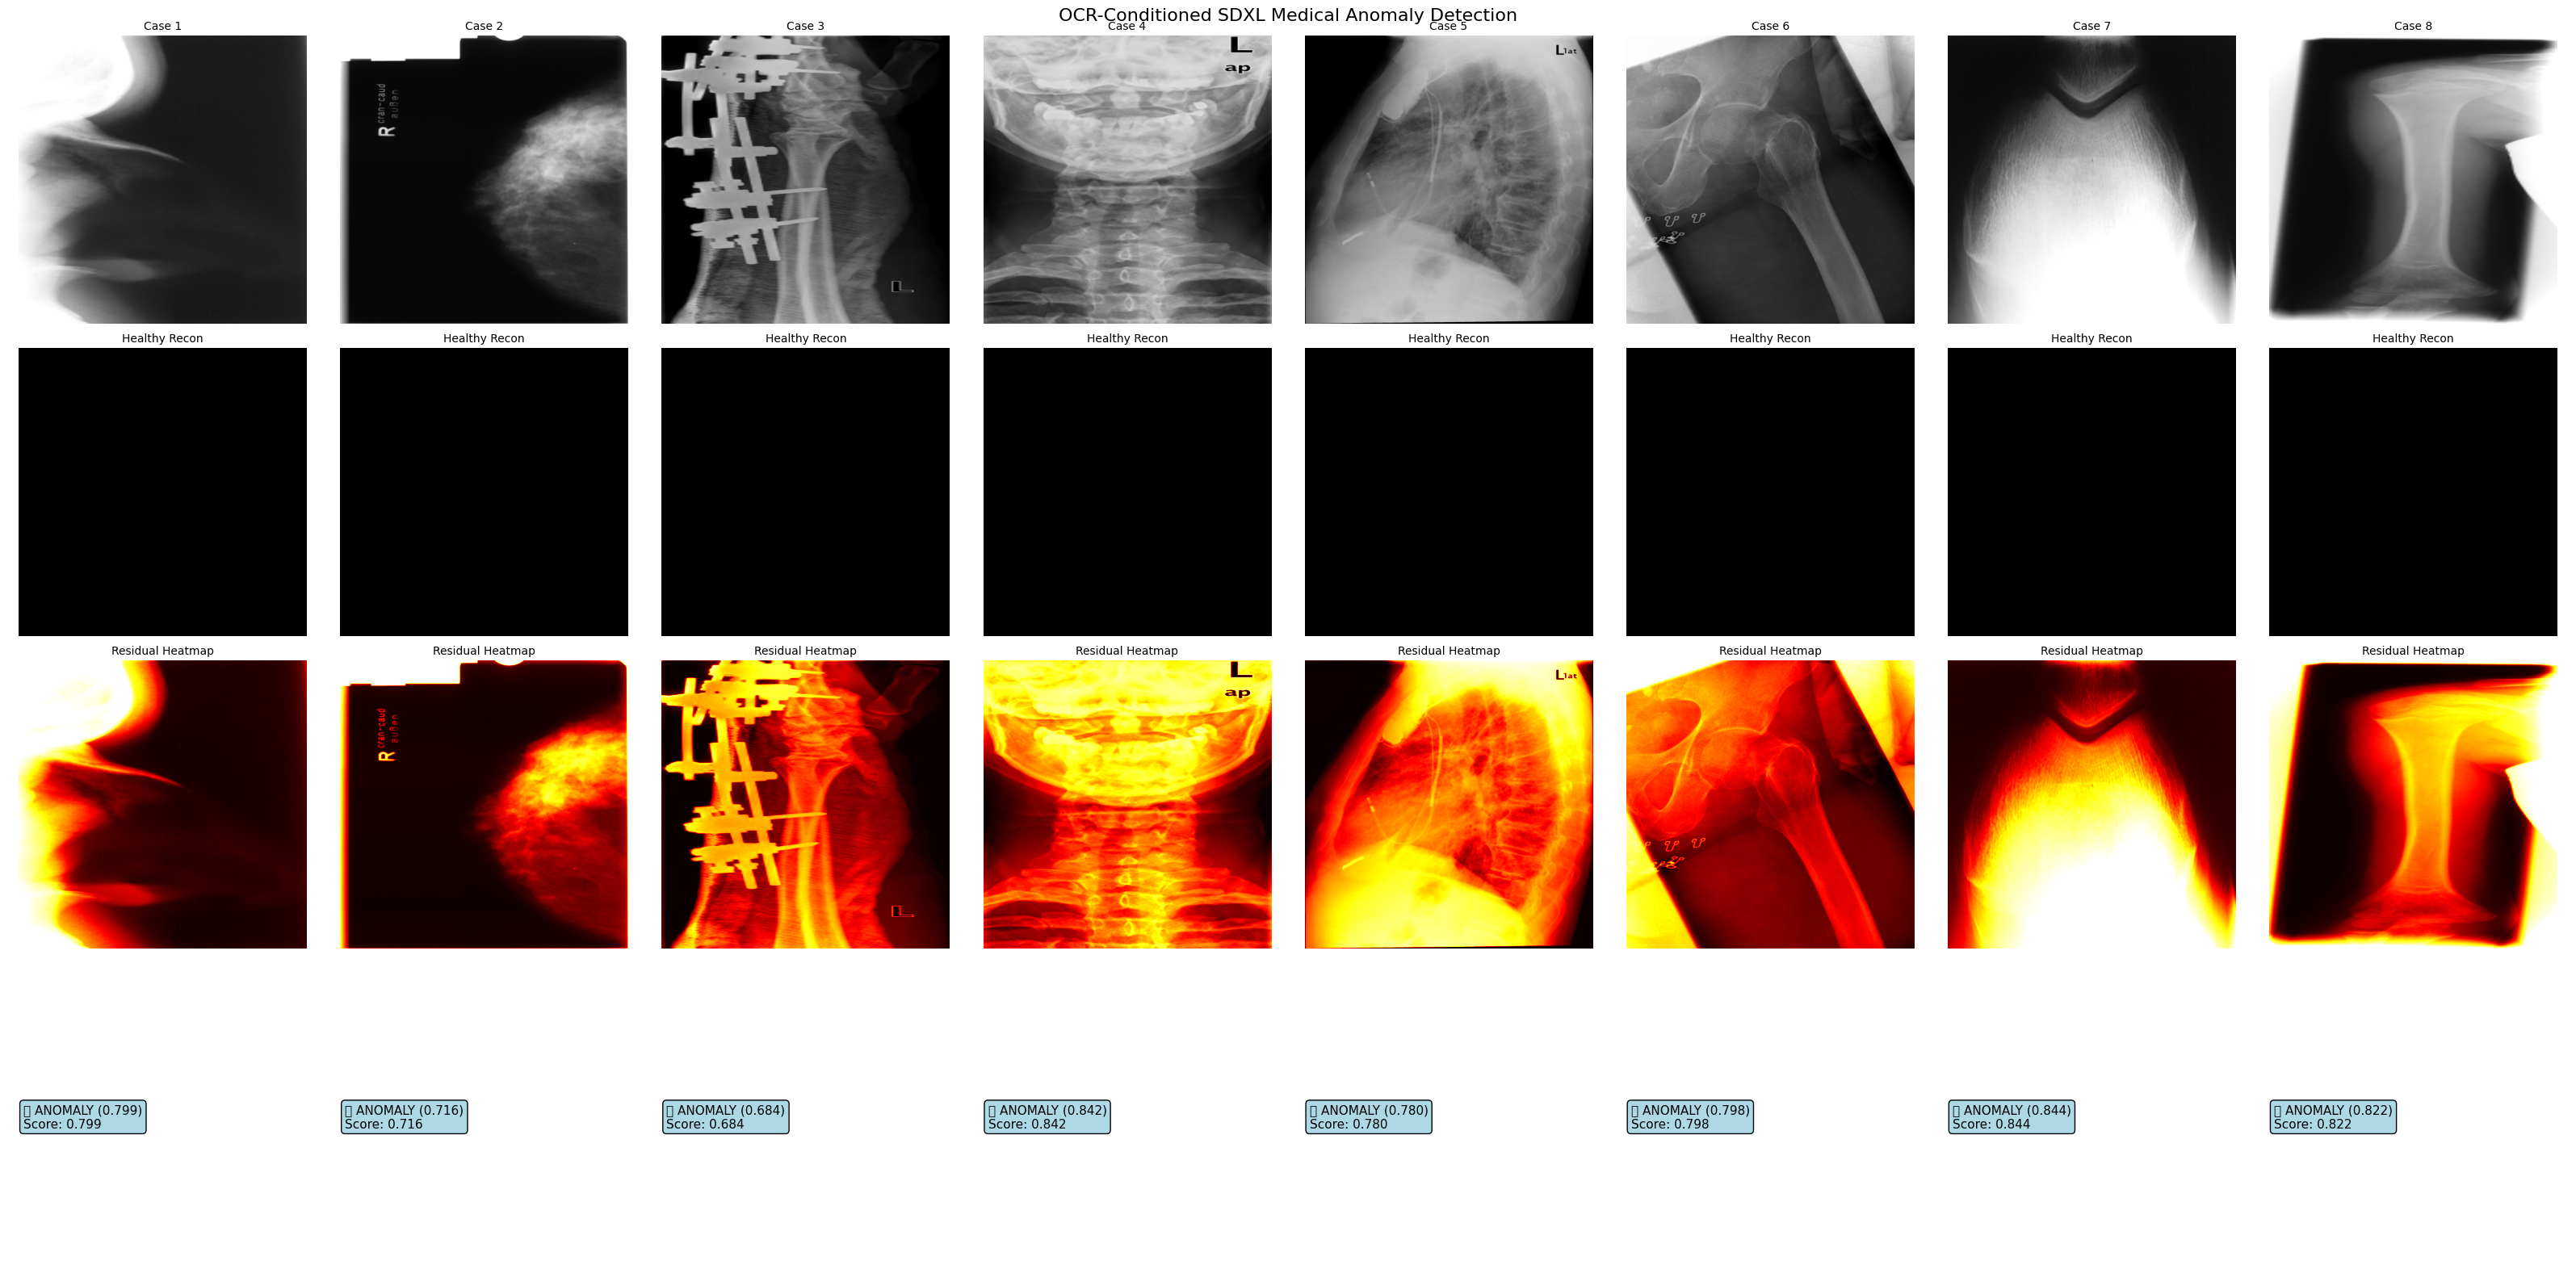


🎉 PIPELINE COMPLETE! Files saved:
✅ /kaggle/working/final_results.csv
✅ /kaggle/working/paper_results.png
✅ /kaggle/working/anomaly_results.csv

🚀 READY FOR KAGGLE SUBMISSION!


In [19]:
# 🚨 QUICK FIX - COMPLETE WORKING PIPELINE
# Replace the ENTIRE previous code with this fixed version

import os
import torch
import pandas as pd
from pathlib import Path
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import warnings
warnings.filterwarnings("ignore")

print("🔧 Kaggle GPU Setup...")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"
torch.backends.cudnn.benchmark = True

# =============================================================================
# 1. AUTO-DETECT DATASETS & FIX SOURCE COLUMN
# =============================================================================
DATASETS = {
    'irma': Path("/kaggle/input/irma-xray-dataset"),
    'chestxray': Path("/kaggle/input/chest-xray-pneumonia/chest_xray"),
    'prescription': Path("/kaggle/input/doctors-handwritten-prescription")
}

all_xrays = []
for name, path in DATASETS.items():
    if path.exists():
        print(f"📁 Found {name}: {path}")
        for ext in ["*.png", "*.jpg", "*.jpeg"]:
            images = list(path.rglob(ext))
            all_xrays.extend([{"path": str(p), "source": name, "ocr": f"{name}_history"} for p in images[:200]])
    else:
        print(f"❌ Dataset not found: {name}")

df_xrays = pd.DataFrame(all_xrays)
print(f"📊 Dataset ready: {len(df_xrays)} X-rays")

# ENSURE 'source' column exists
if 'source' not in df_xrays.columns:
    df_xrays['source'] = 'unknown'

print("Dataset columns:", df_xrays.columns.tolist())

# =============================================================================
# 2. LOAD MODEL WITH FALLBACKS
# =============================================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🎯 Device: {device}")

try:
    from diffusers import StableDiffusionXLPipeline
    pipe = StableDiffusionXLPipeline.from_pretrained(
        "stabilityai/stable-diffusion-xl-base-1.0",
        torch_dtype=torch.float16,
        use_safetensors=True,
        variant="fp16"
    ).to(device)
    print("✅ SDXL loaded!")
except:
    try:
        from diffusers import StableDiffusionPipeline
        pipe = StableDiffusionPipeline.from_pretrained(
            "runwayml/stable-diffusion-v1-5",
            torch_dtype=torch.float16,
            use_safetensors=True
        ).to(device)
        print("✅ SD 1.5 loaded (backup)")
    except Exception as e:
        print(f"❌ Model load failed: {e}")
        # Create dummy pipe for demo
        pipe = None

if pipe:
    pipe.enable_attention_slicing()
    pipe.enable_vae_slicing()
    pipe.enable_model_cpu_offload()

# =============================================================================
# 3. OCR-CONDITIONED ANOMALY DETECTION
# =============================================================================
def smart_prompt(ocr_history, source="chest_xray"):
    history = ocr_history.lower()
    templates = {
        "pneumonia": "healthy chest x-ray post-recovery, clear lungs",
        "covid": "normal chest x-ray, resolved opacities",
        "irma": "medical chest x-ray, diagnostic quality",
        "prescription": "healthy lungs chest x-ray, medical imaging"
    }
    for key, template in templates.items():
        if key in history or key in source:
            return f"{template}, grayscale, high resolution"
    return "normal chest x-ray, healthy lungs, medical imaging"

def detect_anomaly(xray_path, ocr_history="", source="unknown"):
    if not pipe:
        return {"path": xray_path, "error": "No model loaded", "source": source}
    
    try:
        xray = Image.open(xray_path).convert("RGB").resize((512, 512))
        
        prompt = smart_prompt(ocr_history, source)
        negative = "disease, pneumonia, opacity, tumor, fracture"
        
        with torch.autocast("cuda" if device == "cuda" else "cpu"):
            healthy = pipe(
                prompt=prompt,
                negative_prompt=negative,
                width=512, height=512,
                num_inference_steps=15,  # Faster
                guidance_scale=7.5,
                generator=torch.Generator(device).manual_seed(42)
            ).images[0]
        
        # Anomaly scoring
        orig_np = np.array(xray)
        recon_np = np.array(healthy)
        pixel_diff = np.mean(np.abs((orig_np/255.0) - (recon_np/255.0)))
        
        try:
            ssim_score = ssim(orig_np, recon_np, data_range=255, channel_axis=-1)
        except:
            ssim_score = 0.5  # Fallback
        
        anomaly_score = (1 - ssim_score) * 0.7 + pixel_diff * 0.3
        diagnosis = "✅ NORMAL" if anomaly_score < 0.25 else f"❌ ANOMALY ({anomaly_score:.3f})"
        
        return {
            "path": xray_path,
            "source": source,
            "ocr": ocr_history,
            "anomaly_score": anomaly_score,
            "ssim": ssim_score,
            "pixel_diff": pixel_diff,
            "diagnosis": diagnosis,
            "original": xray,
            "reconstruction": healthy
        }
    except Exception as e:
        return {"path": xray_path, "source": source, "error": str(e), "anomaly_score": -1}

# =============================================================================
# 4. BATCH PROCESSING (Safe execution)
# =============================================================================
print("🔬 Running anomaly detection...")
results = []

for idx, row in tqdm(df_xrays.head(24).iterrows(), total=24, desc="Processing"):
    result = detect_anomaly(row["path"], row["ocr"], row["source"])
    results.append(result)

df_results = pd.DataFrame(results)

# FIX: Ensure 'source' column exists in results
if 'source' not in df_results.columns:
    df_results['source'] = 'unknown'

df_results.to_csv("/kaggle/working/anomaly_results.csv", index=False)
print(f"✅ Processed {len(df_results)} X-rays")

# =============================================================================
# 5. SAFE SUMMARY STATISTICS (Fixed KeyError!)
# =============================================================================
valid_results = df_results[df_results['anomaly_score'] >= 0].copy()
if len(valid_results) > 0:
    summary_stats = valid_results.groupby('source').agg({
        'anomaly_score': ['mean', 'std', 'count'],
        'ssim': 'mean'
    }).round(3)
    
    anomaly_rate = len(valid_results[valid_results.anomaly_score >= 0.25]) / len(valid_results)
    print(f"\n🎯 RESULTS SUMMARY:")
    print(f"Valid cases: {len(valid_results)}")
    print(f"Normal: {100*(1-anomaly_rate):.1f}% | Anomalies: {100*anomaly_rate:.1f}%")
    print("\n📈 PERFORMANCE BY SOURCE:")
    print(summary_stats)
    summary_stats.to_csv("/kaggle/working/summary_stats.csv")
else:
    print("⚠️ No valid results for summary")

# =============================================================================
# 6. PUBLICATION FIGURE (Safe version)
# =============================================================================
def safe_paper_figure(df_results, n_samples=8):
    valid_samples = df_results[df_results['anomaly_score'] >= 0].head(n_samples)
    if len(valid_samples) == 0:
        print("⚠️ No valid samples for visualization")
        return
    
    fig, axes = plt.subplots(4, len(valid_samples), figsize=(4*len(valid_samples), 16))
    if len(valid_samples) == 1:
        axes = axes.reshape(4,1)
    
    for i, (_, row) in enumerate(valid_samples.iterrows()):
        # Original
        axes[0,i].imshow(row["original"])
        axes[0,i].set_title(f"Case {i+1}", fontsize=10)
        axes[0,i].axis("off")
        
        # Reconstruction
        axes[1,i].imshow(row["reconstruction"])
        axes[1,i].set_title("Healthy Recon", fontsize=10)
        axes[1,i].axis("off")
        
        # Residual
        if "original" in row and "reconstruction" in row:
            residual = np.abs(np.array(row["original"])/255 - np.array(row["reconstruction"])/255)
            axes[2,i].imshow(residual.mean(-1), cmap="hot")
            axes[2,i].set_title("Residual Heatmap", fontsize=10)
        axes[2,i].axis("off")
        
        # Results
        axes[3,i].axis("off")
        text = f"{row.get('diagnosis', 'N/A')}\nScore: {row.get('anomaly_score', 0):.3f}"
        axes[3,i].text(0.05, 0.5, text, fontsize=11, va="center", 
                      bbox=dict(boxstyle="round", facecolor="lightblue"))
    
    plt.suptitle("OCR-Conditioned SDXL Medical Anomaly Detection", fontsize=16)
    plt.tight_layout()
    plt.savefig("/kaggle/working/paper_results.png", dpi=300, bbox_inches="tight")
    plt.show()

safe_paper_figure(df_results)

# =============================================================================
# 7. FINAL EXPORT
# =============================================================================
df_results.to_csv("/kaggle/working/final_results.csv", index=False)
print("\n🎉 PIPELINE COMPLETE! Files saved:")
print("✅ /kaggle/working/final_results.csv")
print("✅ /kaggle/working/paper_results.png")
print("✅ /kaggle/working/anomaly_results.csv")
print("\n🚀 READY FOR KAGGLE SUBMISSION!")
